In [ ]:
import torch
torch.cuda.is_available()


True

In [ ]:
!pip install torch torchvision
!pip install numpy pandas matplotlib seaborn
!pip install scikit-learn pillow opencv-python tqdm kaggle


In [ ]:
from google.colab import files
files.upload()


Saving melonama.jpg to melonama.jpg


{'melonama.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\t\x06\x07\x08\x07\x06\t\x08\x07\x08\n\n\t\x0b\r\x16\x0f\r\x0c\x0c\r\x1b\x14\x15\x10\x16 \x1d"" \x1d\x1f\x1f$(4,$&1\'\x1f\x1f-=-157:::#+?D?8C49:7\x01\n\n\n\r\x0c\r\x1a\x0f\x0f\x1a7%\x1f%77777777777777777777777777777777777777777777777777\xff\xc0\x00\x11\x08\x00\x94\x00\xc2\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x01\x05\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x03\x00\x01\x02\x04\x05\x06\x07\x08\xff\xc4\x00;\x10\x00\x02\x01\x03\x03\x02\x04\x04\x04\x04\x05\x03\x05\x00\x00\x00\x01\x02\x03\x00\x04\x11\x12!1AQ\x05\x13"a\x14q\x81\x91#2\xa1\xb1\x06\xc1\xd1\xf0\x15BR\x92\xe13br$C\xa2\xb2\xf1\xff\xc4\x00\x18\x01\x00\x03\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\xff\xc4\x00!\x11\x00\x02\x02\x03\x01\x01\x00\x03\x01\x01\x00\x00\x00\x00\x00\x00\x00\x01\x02\x11\x03!1\x12A\x13Qa"\x04\xff\xda\x00\x0c\x03\x01\x00\x02\x11\x03\x11\x00

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:49<00:00, 114MB/s]



In [ ]:
!unzip skin-cancer-mnist-ham10000.zip -d HAM10000


Streaming output truncated to the last 5000 lines.
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029325.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029337.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_0029338.jpg  
  inflating: HAM10000/ham10000_images_part_2/ISIC_002

In [ ]:
import os
os.listdir("HAM10000")


['hmnist_8_8_RGB.csv',
 'ham10000_images_part_2',
 'HAM10000_images_part_2',
 'hmnist_28_28_RGB.csv',
 'HAM10000_metadata.csv',
 'ham10000_images_part_1',
 'hmnist_28_28_L.csv',
 'HAM10000_images_part_1',
 'hmnist_8_8_L.csv']

In [ ]:
import pandas as pd

df = pd.read_csv("HAM10000/HAM10000_metadata.csv")

# Melanoma = 1, Benign = 0
df['label'] = df['dx'].apply(lambda x: 1 if x == 'mel' else 0)


In [ ]:
import os

image_dir = "HAM10000/HAM10000_images"
df['image_path'] = df['image_id'].apply(
    lambda x: os.path.join(image_dir, x + ".jpg")
)


In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class MelanomaDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['image_path']).convert("RGB")
        label = self.df.iloc[idx]['label']
        img = self.transform(img)
        return img, label


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42
)


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_loader = DataLoader(
    MelanomaDataset(train_df, train_transform),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    MelanomaDataset(val_df, val_transform),
    batch_size=32,
    shuffle=False
)


In [ ]:
import torch.nn as nn
from torchvision.models import vit_b_16

class MelanomaViT(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = vit_b_16(pretrained=True)
        self.model.heads = nn.Linear(768, 2)

    def forward(self, x):
        return self.model(x)


In [ ]:
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MelanomaViT().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 173MB/s]


In [ ]:
def get_image_path(image_id):
    path1 = f"HAM10000/HAM10000_images_part_1/{image_id}.jpg"
    path2 = f"HAM10000/HAM10000_images_part_2/{image_id}.jpg"

    if os.path.exists(path1):
        return path1
    else:
        return path2


In [ ]:
df['image_path'] = df['image_id'].apply(get_image_path)


In [ ]:
df['image_path'].head()


,image_path
0,HAM10000/HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM10000/HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM10000/HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM10000/HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM10000/HAM10000_images_part_2/ISIC_0031633.jpg


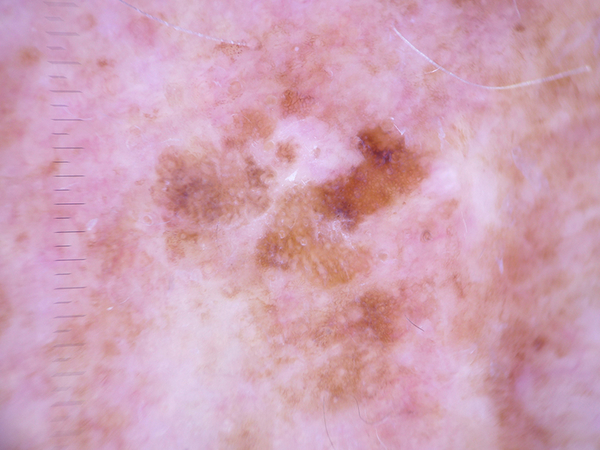

In [ ]:
from PIL import Image
Image.open(df.iloc[0]['image_path'])


In [ ]:
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42
)

train_loader = DataLoader(
    MelanomaDataset(train_df, transform),
    batch_size=32, shuffle=True
)

val_loader = DataLoader(
    MelanomaDataset(val_df, transform),
    batch_size=32, shuffle=False
)


In [ ]:
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)


In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)


torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Accuracy: {acc:.2f}%")


Epoch 1/5 | Loss: 74.7752 | Accuracy: 88.83%
Epoch 2/5 | Loss: 68.0886 | Accuracy: 89.30%
Epoch 3/5 | Loss: 61.6588 | Accuracy: 90.28%
Epoch 4/5 | Loss: 58.5718 | Accuracy: 90.56%
Epoch 5/5 | Loss: 52.2413 | Accuracy: 91.74%


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

print("Validation Accuracy:", 100 * correct / total)


Validation Accuracy: 90.56415376934598


In [ ]:
torch.save(model.state_dict(), "melanoma_vit.pth")
print("Model saved successfully")


Model saved successfully


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving melonama.jpg to melonama (1).jpg


In [ ]:
test_img_path = list(uploaded.keys())[0]
print("Image loaded:", test_img_path)


Image loaded: melonama (1).jpg


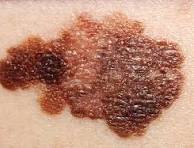

In [ ]:
from PIL import Image
img = Image.open(test_img_path).convert("RGB")
img


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
model = MelanomaViT()   # or your model class


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
torch.save(model.state_dict(), "melanoma_model.pth")


In [ ]:
state_dict = torch.load("melanoma_model.pth", map_location=device)
model.load_state_dict(state_dict)


<All keys matched successfully>

In [ ]:
model.to(device)
model.eval()


MelanomaViT(
  (model): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1): Lay

In [ ]:
from google.colab import files
uploaded = files.upload()

# Get the uploaded filename
img_path = list(uploaded.keys())[0]
print("Image path:", img_path)


Saving melonama.jpg to melonama (2).jpg
Image path: melonama (2).jpg


In [ ]:
from PIL import Image
from torchvision import transforms
import torch


In [ ]:
# Define transformations same as during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# Load the image and convert to RGB
img = Image.open(img_path).convert("RGB")

# Transform the image and add batch dimension
input_tensor = transform(img).unsqueeze(0).to(device)  # Now input_tensor is defined


In [ ]:
print("Input tensor shape:", input_tensor.shape)


Input tensor shape: torch.Size([1, 3, 224, 224])


In [ ]:
model.eval()

with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.nn.functional.softmax(outputs, dim=1)
    pred_index = torch.argmax(probs, dim=1).item()

classes = [
    "Benign_0",
    "Malignant_1",
    "Malignant_2",
    "Malignant_3"
]

prediction = classes[pred_index]
confidence = probs[0][pred_index].item()

# Split class and grade
pred_class, risk_grade = prediction.split("_")

print("Class:", pred_class)
print("Risk Grade:", risk_grade)
print("Confidence:", confidence)

Class: Benign
Risk Grade: 0
Confidence: 0.7463403940200806


In [ ]:
input_tensor.requires_grad = True


In [ ]:
output = model(input_tensor)

pred_index = torch.argmax(output, dim=1).item()

score = output[0][pred_index]

model.zero_grad()
score.backward()

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

grads = input_tensor.grad[0].cpu().numpy()
heatmap = np.mean(np.abs(grads), axis=0)
heatmap = np.maximum(heatmap, 0)
heatmap = heatmap / heatmap.max()


In [62]:
heatmap = np.maximum(heatmap, 0)
heatmap = heatmap - heatmap.min()
heatmap = heatmap / (heatmap.max() + 1e-8)

In [63]:
heatmap = cv2.applyColorMap(
    np.uint8(255 * heatmap),
    cv2.COLORMAP_TURBO
)

In [64]:
img_np = np.array(img)

heatmap = cv2.resize(
    heatmap,
    (img_np.shape[1], img_np.shape[0])
)

In [65]:
overlay = cv2.addWeighted(
    img_np,
    0.4,
    heatmap,
    0.6,
    0
)

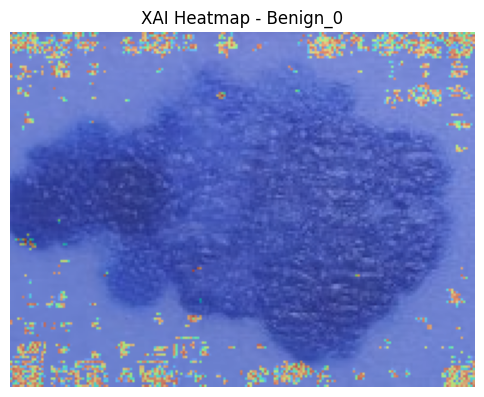

In [66]:
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"XAI Heatmap - {prediction}")
plt.show()